<a href="https://colab.research.google.com/github/Emil-888/Data-Science/blob/main/Copia_de_09_validacion_cruzada_metricas_para_completar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Versión para completar.** Validación cruzada y métricas.
> Solución: `09_validacion_cruzada_metricas.ipynb`.
> Teoría: `09_teoria_validacion_cruzada_metricas.pdf`.
> CSV: `Penguins.csv`.

# UDECATALUNA — para completar
_________________________________

Tema: Modelos de Aprendizaje — **Validación cruzada y métricas**
_________________________________

**Dataset:** `Penguins.csv`  
**Clasificación:** `DecisionTreeClassifier` → especie  
**Regresión:** `LinearRegression` → peso

## Objetivo

Al terminar vas a poder:

* Explicar por qué **un solo corte** train/val es ruidoso.
* Armar **K pliegues** en el train (`StratifiedKFold`) y leer **media ± desvío**.
* Elegir **una** métrica de selección y dejar las otras de diagnóstico.
* Comparar contra el **dummy** también en CV.
* Mirar el **test una vez**, después de elegir.

> La validación cruzada no crea datos. Reusa el train. El test no entra a ningún pliegue.

**Reglas de esta clase**

1. Los pliegues se arman **solo** con el train.
2. Se elige **una** métrica para decidir. Las demás se miran, no se usan para pelear.
3. Se publica `cv_mean ± cv_std` y, al final, el número de **test**.
4. El código va seguido. Sin `armar_modelo()`.

| Palabra | Qué es |
|---|---|
| **Pliegue (fold)** | Un pedazo del train. Una vez es val; las otras veces, entrena. |
| **K** | Cuántos pedazos. Casi siempre 5. |
| **scoring** | La métrica que `cross_val_score` promedia. |
| **Dummy** | El piso. Si el modelo no lo gana en CV, no hay modelo. |

In [10]:
# PASO 1 — Entorno: warnings, plt, np, pd, sns, display.

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (16,8)


### Bloque 1 — Datos y el test se guarda

Misma tabla, dos preguntas. Primero **especie** (clasificación). El test se parte ahora y no vuelve hasta el final.

In [11]:
raw = pd.read_csv("/content/Penguins.csv")
df = raw.dropna().copy()
df = df.rename(columns={
    "species": "especie",
    "island": "isla",
    "bill_length_mm": "pico_largo",
    "bill_depth_mm": "pico_ancho",
    "flipper_length_mm": "aleta",
    "body_mass_g": "peso",
    "sex": "sexo",
})
display(len(df), "filas")
print(df.especie.value_counts().to_string())
display(df.head(3))

333

'filas'

especie
Adelie       146
Gentoo       119
Chinstrap     68


,especie,isla,pico_largo,pico_ancho,aleta,peso,sexo
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE


In [12]:
# PASO 3 — Split clasificación stratify 0.25. El test no se usa en la CV.
from sklearn.model_selection import train_test_split
num_c = ["pico_largo", "pico_ancho", "aleta", "peso"]
cat_c = ["isla", "sexo"]
xc = df[num_c + cat_c]
yc = df["especie"]
xc_train, xc_test, yc_train, yc_test = train_test_split(
    xc, yc, test_size=0.25, random_state=40, stratify=yc)

# de aca nos quedamos con 249 registros de entrenamiento y 284 de testeo


### Bloque 2 — Un solo corte es un sorteo

Si partís el train en train interno / val **una** vez, el accuracy de val cambia con la semilla.  
Cinco cortes, mismo árbol (`max_depth=3`). El número baila.

In [21]:
# PASO 4 — Cinco cortes train/val (seeds 0..4), mismo árbol depth=3. Tabla acc_val.
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
prep_c = ColumnTransformer([
    ("num", "passthrough", num_c),
    ("cat", OneHotEncoder(), cat_c),
])
ruido = []
for seed in [0, 1, 2, 3, 4, 5]:
  x_tr, x_val, y_tr, y_val = train_test_split(
      xc_train, yc_train, test_size=0.25, random_state=seed, stratify=yc_train
  )
  # de esos 249 iniciales nos quedan 187 <- de entrenamiento y 62 <- de testeo

  pipe = Pipeline([
      ("prep", prep_c),
      ("clf", DecisionTreeClassifier(max_depth=3, random_state=40)),
  ])
  pipe.fit(x_tr, y_tr)
  ruido.append({
      "seed": seed,
      "n_val": len(x_val),
      "acc_val": accuracy_score(y_val, pipe.predict(x_val)),
  })
tab_ruido = pd.DataFrame(ruido)
display(tab_ruido.round(2))
print("minimo", round(tab_ruido.acc_val.min(), 2))
print("maximo", round(tab_ruido.acc_val.max(), 2))
print("Elegir un modelo con un val es apostar a la semilla")



,seed,n_val,acc_val
0,0,63,0.97
1,1,63,0.98
2,2,63,0.97
3,3,63,0.94
4,4,63,0.98
5,5,63,0.94


minimo 0.94
maximo 0.98
Elegir un modelo con un val es apostar a la semilla


### Bloque 3 — K pliegues: cada fila del train es val una vez

`K=5`: el train se parte en 5. En cada ronda, 4 pedazos entrenan y 1 valida.  
Se promedian 5 accuracies. Eso es **validación cruzada**.

```
train
  pliegue 1 = VAL     2,3,4,5 = train
  pliegue 2 = VAL     1,3,4,5 = train
  ...
  pliegue 5 = VAL     1,2,3,4 = train
```

**StratifiedKFold:** cada pliegue copia la mezcla de especies. Si no, un val puede quedar sin Chinstrap.

In [22]:
# PASO 5 — StratifiedKFold 5: imprimí Chinstrap/Adelie/Gentoo de cada VAL.
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Chinstrap / Adelie / Gentoo en cada validacion deberia parecerse")
for i, (idx_tr, idx_va) in enumerate(cv.split(xc_train, yc_train), 1):
   y_va = yc_train.iloc[idx_va]
   vc = y_va.value_counts()
   print(
       f"pliegue {i}, n={len(idx_va):3d}"
       f" Chinstrap={vc.get('Chinstrap', 0):2d}"
       f" Adelie={vc.get('Adelie', 0):2d}"
       f" Gentoo={vc.get('Gentoo', 0):2d}"
   )
print("El test no aparece. len(train)=", len(xc_train))

Chinstrap / Adelie / Gentoo en cada validacion deberia parecerse
pliegue 1, n= 50 Chinstrap=10 Adelie=22 Gentoo=18
pliegue 2, n= 50 Chinstrap=10 Adelie=22 Gentoo=18
pliegue 3, n= 50 Chinstrap=10 Adelie=22 Gentoo=18
pliegue 4, n= 50 Chinstrap=11 Adelie=22 Gentoo=17
pliegue 5, n= 49 Chinstrap=10 Adelie=21 Gentoo=18
El test no aparece. len(train)= 249


### Bloque 4 — `cross_val_score`: lo mismo, una línea

Sklearn hace el loop. `scoring="accuracy"` es la métrica de **esta** CV.  
Se reporta **media ± desvío**. El desvío grande = el número es inestable.

In [26]:
# PASO 6 — cross_val_score del árbol depth=3: pliegues, cv_mean, cv_std.
from sklearn.model_selection import cross_val_score
arbol = Pipeline([
    ("prep", prep_c),
    ("clf", DecisionTreeClassifier(max_depth=3, random_state=40)),
])
scores = cross_val_score(arbol, xc_train, yc_train, cv=cv, scoring="accuracy")
print("plieges : ", np.round(scores, 3).tolist())
print("cv_mean : ", round(scores.mean(), 3))
print("cv_std  : ", round(scores.std(), 3))
print("Eso se lee: accuracy cv ="
        f"{scores.mean():.3f} +- {scores.std():.3f}.   (k=5), solo de entrenamiento")


plieges :  [0.98, 0.96, 0.96, 0.98, 0.939]
cv_mean :  0.964
cv_std  :  0.015
Eso se lee: accuracy cv =0.964 +- 0.015.   (k=5), solo de entrenamiento


In [23]:
# PASO 6 — cross_val_score del árbol depth=3: pliegues, cv_mean, cv_std.
from sklearn.model_selection import cross_val_score
arbol = Pipeline([
    ("prep", prep_c),
    ("clf", DecisionTreeClassifier(max_depth=3, random_state=40)),
])
scores = cross_val_score(arbol, xc_train, yc_train, cv=cv, scoring="accuracy")
print("plieges : ", np.round(scores, 3).tolist())
print("cv_mean : ", round(scores.mean(), 3))
print("cv_std  : ", round(scores.std(), 3))
print("Eso se lee: accuracy cv ="
        f"{scores.mean():.3f} +- {scores.std():.3f}.   (k=5), solo de entrenamiento")


plieges :  [0.98, 0.96, 0.96, 0.98, 0.939]
cv_mean :  0.964
cv_std  :  0.015
Eso se lee: accuracy cv =0.964 +- 0.015.   (k=5), solo de entrenamiento


### Bloque 5 — ¿K = 3, 5 o 10?

Más pliegues: cada val es más chico, el desvío suele cambiar, tarda más.  
En este curso, **K=5** alcanza. No se declara ganador por 0.004.

In [28]:
# PASO 7 — Tabla K = 3, 5, 10: cv_mean y cv_std.

filas_k = []
for k in [3, 5, 10]:
  cvk = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
  scores = cross_val_score(arbol, xc_train, yc_train, cv=cvk, scoring="accuracy")
  filas_k.append({
      "k":k,
      "cv_mean": scores.mean(),
      "cv_std": scores.std(),
      "n_val_aprox": len(xc_train) // k
  })
tab_k = pd.DataFrame(filas_k)
display(tab_k.round(3))
print("La media se mueve poco, el desvio si puede cambiar. Nos quedamos con 5 pliegues")

,k,cv_mean,cv_std,n_val_aprox
0,3,0.952,0.010,83
1,5,0.964,0.015,49
2,10,0.960,0.031,24


La media se mueve poco, el desvio si puede cambiar. Nos quedamos con 5 pliegues


### Bloque 6 — El dummy también se cruza

Una métrica sin loro no dice nada. El `DummyClassifier` entra al **mismo** CV.

In [30]:
# PASO 8 — Dummy most_frequent vs árbol, mismo CV. Tabla cv_mean / cv_std.
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent") # ->
s_dummy = cross_val_score(dummy, xc_train, yc_train, cv=cv, scoring="accuracy")
s_arbol = cross_val_score(arbol, xc_train, yc_train, cv=cv, scoring="accuracy")
tab_base = pd.DataFrame({
    "modelo": ["dummy most_frequent", "arbol depth = 3"],
    "cv_mean": [s_dummy.mean(), s_arbol.mean()],
    "cv_std": [s_dummy.std(), s_arbol.std()],
})
display(tab_base.round(3))


,modelo,cv_mean,cv_std
0,dummy most_frequent,0.438,0.005
1,arbol depth = 3,0.964,0.015


### Bloque 7 — Métricas de clasificación (las de siempre)

Después de la CV **ya no se elige nada**. Se reentrena con **todo** el train y se mira el test **una vez**.

* **Accuracy** vs dummy, en el test: ¿hay modelo?
* **Matriz:** ¿con quién se confunde?
* **Reporte:** recall de Chinstrap (la chica). El accuracy puede esconderla.

No se usan 20 números para elegir. Esos tres alcanzan.

Accuracy dummy (test):  0.44
Accuracy arbol (test):  0.94
              precision    recall  f1-score   support

      Adelie      0.921     0.946     0.933        37
   Chinstrap      0.875     0.824     0.848        17
      Gentoo      1.000     1.000     1.000        30

    accuracy                          0.940        84
   macro avg      0.932     0.923     0.927        84
weighted avg      0.940     0.940     0.940        84



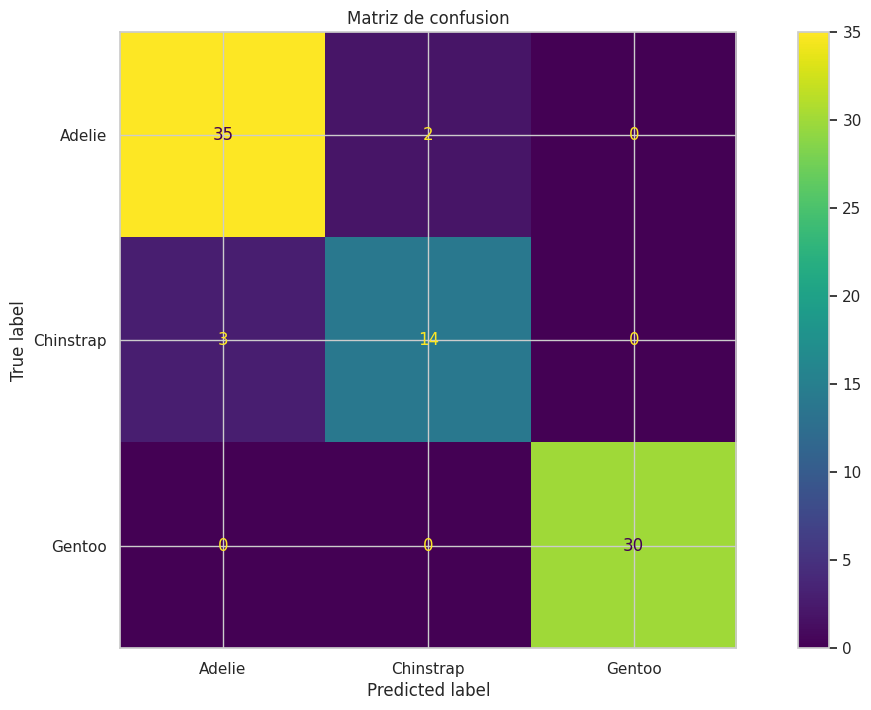

In [31]:
# PASO 9 — Reentrená con TODO el train. Accuracy vs dummy, reporte y matriz en TEST.
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
arbol.fit(xc_train, yc_train)
pred = arbol.predict(xc_test)
pred_dummy = dummy.fit(xc_train, yc_train).predict(xc_test)

print("Accuracy dummy (test): ", round(accuracy_score(yc_test, pred_dummy), 3))
print("Accuracy arbol (test): ", round(accuracy_score(yc_test, pred), 3))
print(classification_report(yc_test, pred, digits = 3))
ConfusionMatrixDisplay.from_predictions(yc_test, pred)
plt.title("Matriz de confusion")
plt.show()

### Bloque 8 — Cambiar el `scoring` cambia la pregunta

`accuracy` premia acertar Adelie (la mayor).  
`f1_macro` le da el **mismo peso** a Chinstrap.  
Se elige **una** para decidir. La otra queda de diagnóstico.

In [32]:
# PASO 10 — Mismo árbol: CV con accuracy y con f1_macro.
s_acc = cross_val_score(arbol, xc_train, yc_train, cv=cv, scoring="accuracy")
s_f1 = cross_val_score(arbol, xc_train, yc_train, cv=cv, scoring="f1_macro")
print("accuracy cv:", round(s_acc.mean(), 3), "+-", round(s_acc.std(), 3))
print("f1_macro cv:", round(s_f1.mean(), 3), "+-", round(s_f1.std(), 3))

accuracy cv: 0.964 +- 0.015
f1_macro cv: 0.961 +- 0.018


### Bloque 9 — Lo mismo en regresión (MAE y R²)

Predecir **peso** con pico y aleta. **Sin** `peso` ni `especie` como feature (fuga).  
Métricas: **MAE** (gramos) y **R²** (contra 0, el loro de la media).

`scoring="neg_mean_absolute_error"`: sklearn **maximiza**. El MAE viene **negado**.  
Para leerlo en gramos: se multiplica por −1.

In [ ]:
# PASO 11 — Regresión peso (pico, pico_ancho, aleta). Dummy media vs LinearRegression.
# MAE y R² en test (ilustración).


In [ ]:
# PASO 12 — KFold 5: neg_MAE del dummy y de la recta (pasalo a gramos). R² de la recta.


### Bloque 10 — Protocolo: CV elige, test examina

Tres depths. Se elige con **accuracy de CV** en el train. Si empatan, el más chico.  
Se reentrena con todo el train. Se mira el test **una vez**.

In [ ]:
# PASO 13 — Depths 1, 3, 8: elegí con CV accuracy (empate → el más chico). Test una vez.


### Ejercicios (para completar)

Solución: `09_validacion_cruzada_metricas.ipynb`.

#### Ejercicio 1 — El test no es un pliegue

Mostrá que `len(Xc_train)` es lo que entra a la CV y que `len(Xc_test)` no se suma.

In [ ]:
# EJ 1 — Filas que fueron VAL vs len(train) vs len(test). El test no es un pliegue.


#### Ejercicio 2 — KFold sin estratificar

Compará Chinstrap por pliegue con `KFold` vs `StratifiedKFold`. Mismo `random_state=0`.

In [ ]:
# EJ 2 — KFold vs StratifiedKFold: Chinstrap por pliegue (random_state=0).


#### Ejercicio 3 — ¿K=10 es 'más preciso'?

Con `tab_k`: ¿la media cambia mucho? ¿El desvío? ¿Vale la pena K=10 acá?

In [ ]:
# EJ 3 — Con tab_k: ¿K=10 cambia la media? ¿Vale la pena?


#### Ejercicio 4 — ¿Hay modelo? Dummy vs árbol en CV

Escribí la diferencia de `cv_mean` (árbol − dummy).

In [ ]:
# EJ 4 — Diferencia cv_mean árbol − dummy.


#### Ejercicio 5 — La métrica de selección

`max_depth` 1 vs 3. Ganador con `accuracy` y con `f1_macro`. ¿El mismo?

In [ ]:
# EJ 5 — Depth 1 vs 3: ganador accuracy vs ganador f1_macro.


#### Ejercicio 6 — Leer la matriz del test

Con las predicciones del bloque 7: ¿Chinstrap se confunde más con Adelie o con Gentoo?

In [ ]:
# EJ 6 — Matriz del test: Chinstrap se confunde más con quién.


#### Ejercicio 7 — `neg_mean_absolute_error` a gramos

Pasá los scores de la recta a MAE positivo. ¿Cuántos gramos de error de CV?

In [ ]:
# EJ 7 — -neg_recta a MAE en gramos (media ± desvío).


#### Ejercicio 8 — R² del dummy en CV

El loro de la media, ¿qué R² saca en los 5 pliegues? ¿Puede ser negativo?

In [ ]:
# EJ 8 — R² del dummy en CV (pliegues). ¿Puede ser negativo?


#### Ejercicio 9 — Elegir con CV, no con el test

Tres depths otra vez. Mostrá el que **ganaría** si (mal) miraras el test, vs el de CV.

In [ ]:
# EJ 9 — Depth 1, 3, 8: ganador CV vs ganador test. El test no se usa para elegir.


#### Ejercicio 10 — Frase para el oral

In [14]:
# EJ 10 — print: qué es CV, qué métrica se publica, cuándo se mira el test.


### Cierre — para decir sin notebook

* Un val solo es un sorteo. CV promedia K sorteos del **train**.
* `StratifiedKFold` en clasificación. `KFold` en regresión. **K=5**.
* Clasificación: accuracy vs dummy + matriz + recall de la chica. Selección: **una** (`accuracy` o `f1_macro`).
* Regresión: MAE vs la media (en gramos). `neg_MAE` se lee multiplicando por −1. R² vs 0.
* Protocolo: split → CV en train → reentrenar → test una vez.

**UDECATALUNA** — Modelos de Aprendizaje · Validación cruzada y métricas